In [18]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"muski2344","key":"1cfbcdea18440e75c0dd4d7a6278f394"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!pip install scikit-image tqdm -q

In [19]:
import urllib.request, zipfile, os

os.makedirs("data/train", exist_ok=True)

print("Downloading... (~800MB, takes 2–3 mins)")
urllib.request.urlretrieve(
    "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip",
    "cats_dogs.zip"
)

print("Unzipping...")
with zipfile.ZipFile("cats_dogs.zip", "r") as z:
    z.extractall("raw")

import shutil
from pathlib import Path

for label in ["Cat", "Dog"]:
    folder = Path(f"raw/PetImages/{label}")
    prefix = label.lower()
    count  = 0
    for img_path in folder.glob("*.jpg"):
        try:
            Image.open(img_path).verify()
            shutil.copy(img_path, f"data/train/{prefix}.{count}.jpg")
            count += 1
        except Exception:
            pass
    print(f"  ✅ {count} {label} images ready")

print("\n✅ Done! Run the SVM script now.")

Downloading... (~800MB, takes 2–3 mins)
Unzipping...
  ✅ 12499 Cat images ready


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


  ✅ 12499 Dog images ready

✅ Done! Run the SVM script now.


Loading 2000 images...


100%|██████████| 2000/2000 [00:13<00:00, 148.55it/s]


Feature vector size: 1568

Training SVM...
Done in 2.5s

Validation Accuracy: 0.6850
              precision    recall  f1-score   support

         cat       0.69      0.66      0.68       200
         dog       0.68      0.71      0.69       200

    accuracy                           0.69       400
   macro avg       0.69      0.69      0.68       400
weighted avg       0.69      0.69      0.68       400



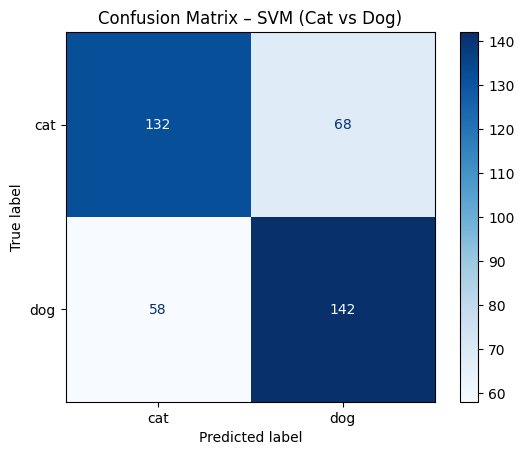

✅ confusion_matrix.png saved


In [20]:
import os
import glob
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

TRAIN_DIR   = "data/train"
IMG_SIZE    = (64, 64)
N_SAMPLES   = 2000
TEST_SIZE   = 0.20
RANDOM_SEED = 42
USE_HOG     = True
N_PCA       = 150

np.random.seed(RANDOM_SEED)

def load_image(path):
    img = Image.open(path).convert("RGB").resize(IMG_SIZE)
    return np.array(img, dtype=np.float32)

def hog_features(img):
    from skimage.feature import hog
    return hog(img, orientations=8, pixels_per_cell=(8,8),
                cells_per_block=(2,2), channel_axis=-1)

def extract_features(img):
    return hog_features(img) if USE_HOG else img.flatten() / 255.0

def load_dataset(train_dir, n_samples):
    per_class = n_samples // 2
    cat_paths = glob.glob(os.path.join(train_dir, "cat.*.jpg"))[:per_class]
    dog_paths = glob.glob(os.path.join(train_dir, "dog.*.jpg"))[:per_class]
    paths  = cat_paths + dog_paths
    labels = ["cat"] * len(cat_paths) + ["dog"] * len(dog_paths)
    print(f"Loading {len(paths)} images...")
    X, y = [], []
    for path, label in tqdm(zip(paths, labels), total=len(paths)):
        try:
            X.append(extract_features(load_image(path)))
            y.append(label)
        except: pass
    return np.array(X, dtype=np.float32), np.array(y)

X, y = load_dataset(TRAIN_DIR, N_SAMPLES)
print(f"Feature vector size: {X.shape[1]}")

le = LabelEncoder()
y_enc = le.fit_transform(y)
X_train, X_val, y_train, y_val = train_test_split(
    X, y_enc, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_enc)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca",    PCA(n_components=N_PCA, random_state=RANDOM_SEED)),
    ("svm",    SVC(C=10, kernel="rbf", gamma="scale", probability=True, random_state=RANDOM_SEED))
])

print("\nTraining SVM...")
t0 = time.time()
pipeline.fit(X_train, y_train)
print(f"Done in {time.time()-t0:.1f}s")

y_pred = pipeline.predict(X_val)
print(f"\nValidation Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print(classification_report(y_val, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_val, y_pred)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(cmap="Blues")
plt.title("Confusion Matrix – SVM (Cat vs Dog)")
plt.savefig("confusion_matrix.png")
plt.show()
print("✅ confusion_matrix.png saved")

Saving cat.18.jpg to cat.18.jpg


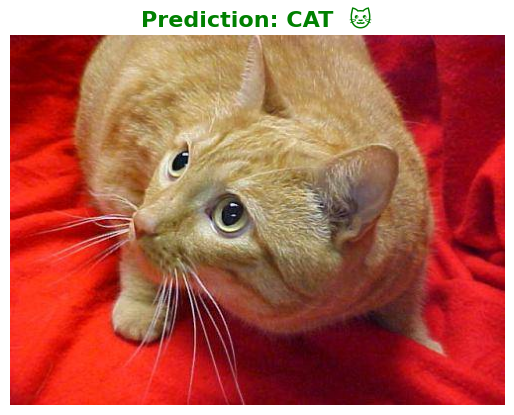


✅ This is a:  CAT
   Cat probability: 58.4%
   Dog probability: 41.6%


In [21]:
from PIL import Image
import numpy as np
from google.colab import files

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

img  = Image.open(img_path).convert("RGB").resize((64, 64))
feat = extract_features(np.array(img, dtype=np.float32))
feat = feat.reshape(1, -1);

pred  = pipeline.predict(feat)[0]
proba = pipeline.predict_proba(feat)[0]
label = le.inverse_transform([pred])[0]

plt.imshow(Image.open(img_path))
plt.axis("off")
plt.title(f"Prediction: {label.upper()}  🐱" if label=="cat" else f"Prediction: {label.upper()}  🐶",
          fontsize=16, fontweight="bold",
          color="green")
plt.show()

print(f"\n✅ This is a:  {label.upper()}")
print(f"   Cat probability: {proba[0]*100:.1f}%")
print(f"   Dog probability: {proba[1]*100:.1f}%")

Saving dog.232.jpg to dog.232 (3).jpg


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


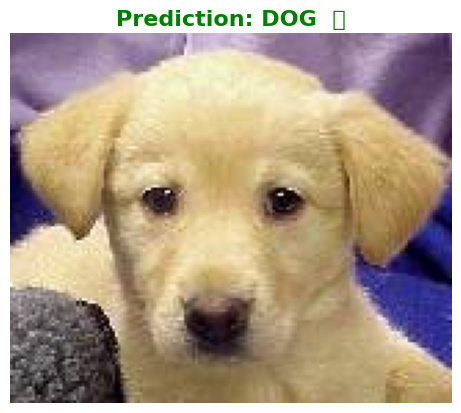


✅ This is a:  DOG
   Cat probability: 3.7%
   Dog probability: 96.3%


In [22]:

from PIL import Image
import numpy as np
from google.colab import files

uploaded = files.upload()
img_path = list(uploaded.keys())[0]


img  = Image.open(img_path).convert("RGB").resize((64, 64))
feat = extract_features(np.array(img, dtype=np.float32))
feat = feat.reshape(1, -1)

pred  = pipeline.predict(feat)[0]
proba = pipeline.predict_proba(feat)[0]
label = le.inverse_transform([pred])[0]


plt.imshow(Image.open(img_path))
plt.axis("off")
plt.title(f"Prediction: {label.upper()}  🐱" if label=="cat" else f"Prediction: {label.upper()}  🐶",
          fontsize=16, fontweight="bold",
          color="green")
plt.show()

print(f"\n✅ This is a:  {label.upper()}")
print(f"   Cat probability: {proba[0]*100:.1f}%")
print(f"   Dog probability: {proba[1]*100:.1f}%")